# Fake vs Real News Classification using LSTM
This notebook downloads the dataset using `kagglehub`, cleans the text data, and trains an LSTM neural network to classify news articles as fake or real.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, GlobalMaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam

# Download required NLTK data directly
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 1. Download and Load Data

In [2]:
# Download latest version of the dataset
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Path to dataset files:", path)

# Load datasets
fake_df = pd.read_csv(os.path.join(path, "Fake.csv"))
true_df = pd.read_csv(os.path.join(path, "True.csv"))

# Assign labels (0 for Fake, 1 for True)
fake_df['label'] = 0
true_df['label'] = 1

# Drop unneeded columns
columns_to_drop = ["title", "date", "subject"]
fake_df.drop(columns=columns_to_drop, inplace=True)
true_df.drop(columns=columns_to_drop, inplace=True)

# Concatenate into one DataFrame and drop duplicates
news_df = pd.concat([fake_df, true_df], ignore_index=True)
news_df.drop_duplicates(inplace=True)

print(f"Total rows after removing duplicates: {len(news_df)}")

100%|██████████| 41.0M/41.0M [00:02<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1
Total rows after removing duplicates: 38647


## 2. Text Preprocessing

In [3]:
nltk.download('punkt_tab')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def process_text(text):
    # Remove extra white spaces and special characters
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub(r'\W', ' ', str(text))
    # Remove single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    # Remove any character that isn't alphabetical
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()

    # Tokenize
    words = word_tokenize(text)

    # Lemmatize, remove stopwords, and remove short words (length <= 3)
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 3
    ]

    # Return as a single string for the Tokenizer
    return ' '.join(cleaned_words)

print("Cleaning text data... This may take a few minutes.")
news_df['clean_text'] = news_df['text'].apply(process_text)

# Split features and labels
X = news_df['clean_text'].values
y = news_df['label'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cleaning text data... This may take a few minutes.


## 3. Tokenization and Padding

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print("Size of vocabulary:", vocab_size)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
maxlen = 150
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

Size of vocabulary: 91947


## 4. Build and Compile the LSTM Model

In [5]:
input_layer = Input(shape=(maxlen,))
x = Embedding(input_dim=vocab_size, output_dim=100)(input_layer)
x = Dropout(0.5)(x)
x = LSTM(150, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

# 1 output neuron with sigmoid activation for binary classification
output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output_layer)

# Using binary_crossentropy since our labels are 0 and 1
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 100)       │     9,194,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 150)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 150)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,355,029 (35.69 MB)

 Trainable params: 9,355,029 (35.69 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [6]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    validation_data=(X_test_pad, y_test),
    batch_size=32
)

Epoch 1/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.8520 - loss: 0.3143 - val_accuracy: 0.9635 - val_loss: 0.1693
Epoch 2/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9722 - loss: 0.0968 - val_accuracy: 0.9704 - val_loss: 0.1322
Epoch 3/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9851 - loss: 0.0546 - val_accuracy: 0.9744 - val_loss: 0.1002
Epoch 4/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9905 - loss: 0.0348 - val_accuracy: 0.9739 - val_loss: 0.0915
Epoch 5/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9942 - loss: 0.0230 - val_accuracy: 0.9740 - val_loss: 0.0889
Epoch 6/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9954 - loss: 0.0170 - val_accuracy: 0.9732 - val_loss: 0.0841
Epoch 7/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9966 - loss: 0.0130 - val_accuracy: 0.9712 - val_loss: 0.0788
Epoch 8/15
967/967 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9980 - loss: 0.0088 - 

## 6. Evaluation and Visualization

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9730 - loss: 0.0874
Test Loss: 0.0874
Test Accuracy: 0.9730


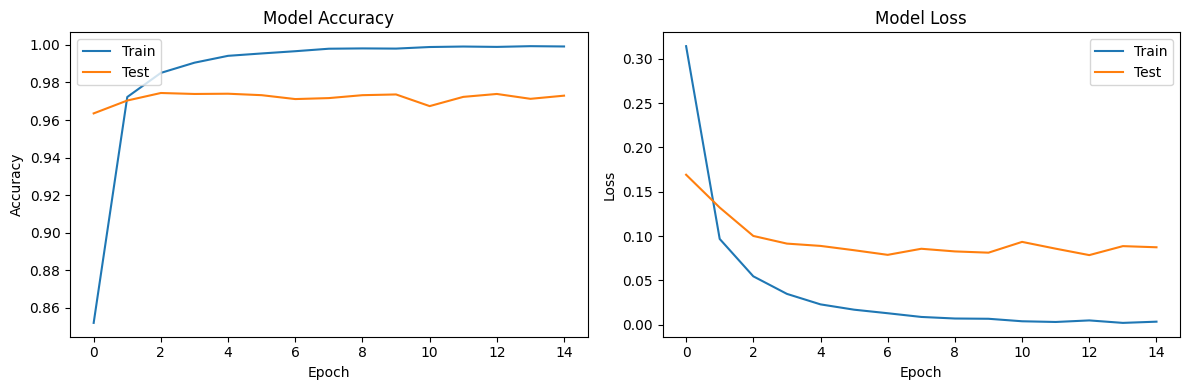

In [7]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training & validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


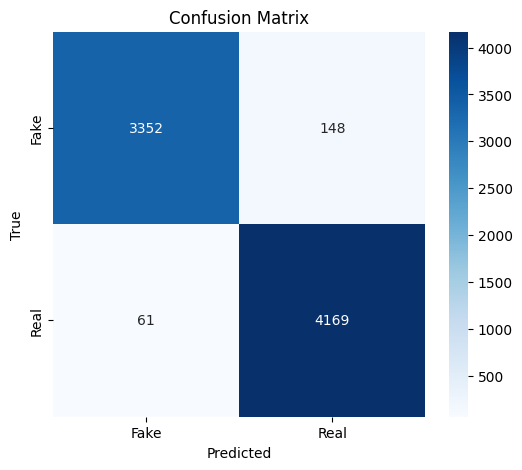

In [8]:
# Confusion Matrix
y_pred_probs = model.predict(X_test_pad)
y_pred_labels = (y_pred_probs > 0.5).astype(int).flatten()

conf_matrix = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [9]:
# Save the trained model
model_filename = 'fake_news_lstm_model.keras'
model.save(model_filename)

print(f"Model saved successfully as {model_filename}!")

Model saved successfully as fake_news_lstm_model.keras!


In [10]:
from google.colab import files
files.download('fake_news_lstm_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>